# Convolutional Neural Network (CNN) on MNIST Dataset

## Objective

The objective of this experiment is to implement a Convolutional Neural Network (CNN) for handwritten digit recognition using the MNIST dataset.

The model is trained to classify digits from 0 to 9 and is further extended to predict custom handwritten digit images uploaded by the user.

This implementation demonstrates the practical application of Deep Learning and Computer Vision using CNNs.

# About the MNIST Dataset

MNIST is one of the most popular datasets used for learning and benchmarking image classification algorithms.

Dataset Characteristics:

- 70,000 handwritten digit images
- 60,000 training images
- 10,000 testing images
- Image size: 28 × 28 pixels
- Grayscale images
- Classes: 10 (Digits 0–9)

The objective is to correctly identify the digit present in each image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Loading the Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


# Visualizing Sample Images

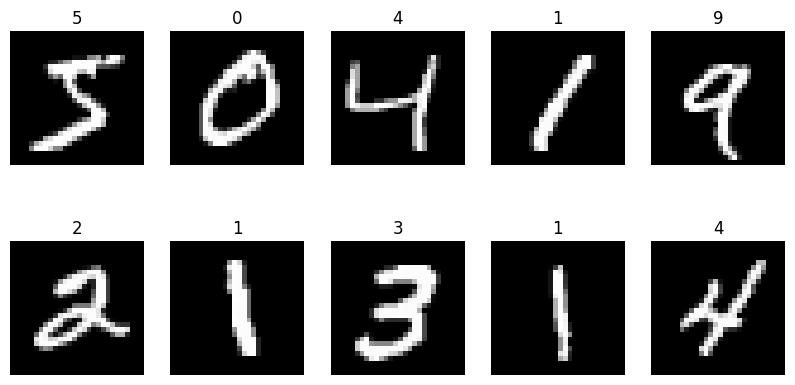

In [3]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

# Data Preprocessing

CNN models perform better when pixel values are normalized.

Original Range:

0 – 255

Normalized Range:

0 – 1

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshaping Data

CNN expects data in:

(height, width, channels)

Since MNIST images are grayscale, channel = 1.

In [5]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

print(x_train.shape)

(60000, 28, 28, 1)


# Building the CNN Model

Architecture:

Input Layer
->
Conv2D
->
MaxPooling
->
Conv2D
->
MaxPooling
->
Flatten
->
Dense Layer
->
Dropout
->
Output Layer

In [6]:
model = keras.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# Compiling the Model

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Training the Model

In [9]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 59s 36ms/step - accuracy: 0.9308 - loss: 0.2289 - val_accuracy: 0.9834 - val_loss: 0.0586
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 76s 33ms/step - accuracy: 0.9727 - loss: 0.0889 - val_accuracy: 0.9887 - val_loss: 0.0405
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 34ms/step - accuracy: 0.9805 - loss: 0.0645 - val_accuracy: 0.9887 - val_loss: 0.0364
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 78s 32ms/step - accuracy: 0.9845 - loss: 0.0506 - val_accuracy: 0.9877 - val_loss: 0.0459
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 33ms/step - accuracy: 0.9858 - loss: 0.0437 - val_accuracy: 0.9906 - val_loss: 0.0349
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.9882 - loss: 0.0367 - val_accuracy: 0.9915 - val_loss: 0.0299
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9893 - loss: 0.0314 - val_accuracy: 0.9903 - val_loss: 0.0348
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 33ms/step - accuracy: 0.9915 -

# Evaluating the Model

In [10]:
test_loss, test_acc = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9917 - loss: 0.0272
Test Accuracy: 0.9916999936103821


# Accuracy Graph

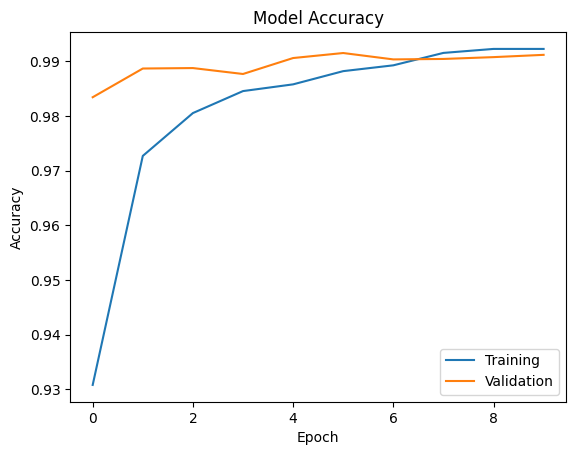

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training","Validation"])

plt.show()

# Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


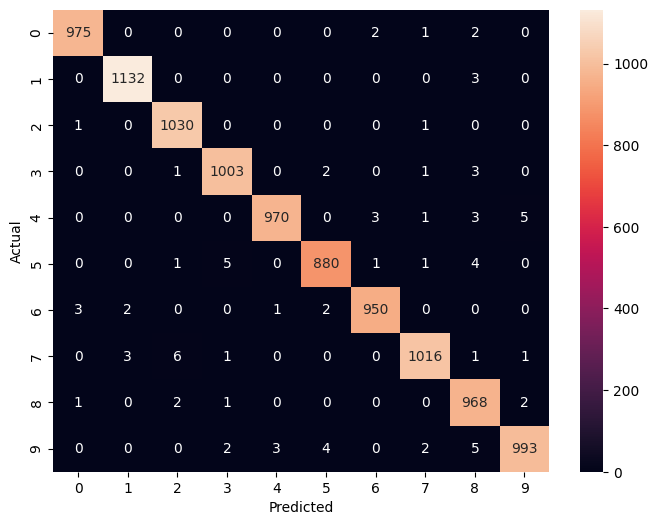

In [12]:
y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(
    y_test,
    y_pred_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Custom Handwritten Digit Prediction

The user can upload a handwritten digit image and allow the CNN model to predict the digit.

In [35]:
from google.colab import files

uploaded = files.upload()

Saving test_photo5.jpeg to test_photo5 (1).jpeg


In [36]:
from PIL import Image

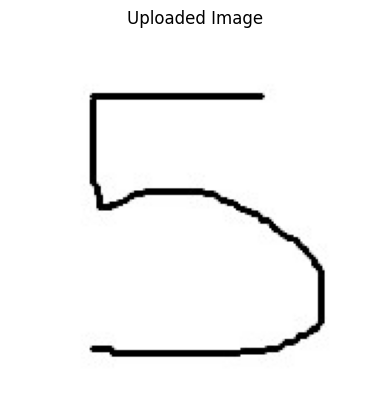

In [37]:
filename = list(uploaded.keys())[0]

img = Image.open(filename).convert("L")

plt.imshow(img, cmap='gray')
plt.title("Uploaded Image")
plt.axis('off')
plt.show()

In [38]:
img = img.resize((28,28))

img_array = np.array(img)

img_array = 255 - img_array

img_array = img_array / 255.0

img_array = img_array.reshape(
    1,
    28,
    28,
    1
)

In [39]:
print(img_array.shape)

(1, 28, 28, 1)


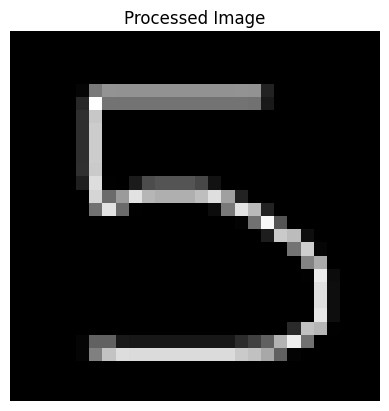

In [40]:
plt.imshow(
    img_array.reshape(28,28),
    cmap='gray'
)

plt.title("Processed Image")
plt.axis('off')
plt.show()

In [41]:
prediction = model.predict(img_array)

digit = np.argmax(prediction)

print("Predicted Digit:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Digit: 5


In [42]:
# Save Trained Model

model.save("mnist_cnn_model.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [44]:
from google.colab import files

files.download("mnist_cnn_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

A Convolutional Neural Network (CNN) was successfully implemented on the MNIST dataset for handwritten digit recognition.

The model achieved high classification accuracy and was further extended to predict custom handwritten digit images uploaded by the user.

This experiment demonstrated the effectiveness of CNNs in image classification tasks and provided practical experience in Deep Learning and Computer Vision.